Leitura dos dados

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("output_notebook_simplificado")
output_dir.mkdir(exist_ok=True, parents=True)

# %%
# 1. Carregar dataset
# df_raw = pd.read_csv("128_fishing_trajsRugs10.csv")
df_raw = pd.read_csv("visem12.csv")
df_raw = df_raw.sort_values(["trajectory_id", "timestamp"]).reset_index(drop=True)
df_raw.head()

,user_id,timestamp,trajectory_id,ftid,x,y,w,h
0,12,0,ckz3vb89a00073867yfftbbpw,0,0.271875,0.369792,0.034375,0.03125
1,12,1,ckz3vb89a00073867yfftbbpw,0,0.246875,0.372917,0.034375,0.03125
2,12,2,ckz3vb89a00073867yfftbbpw,0,0.221875,0.376042,0.034375,0.03125
3,12,3,ckz3vb89a00073867yfftbbpw,0,0.220759,0.376339,0.034375,0.03125
4,12,4,ckz3vb89a00073867yfftbbpw,0,0.219643,0.376637,0.034375,0.03125


C:\Users\ccana\AppData\Local\Temp\ipykernel_4900\3871629169.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


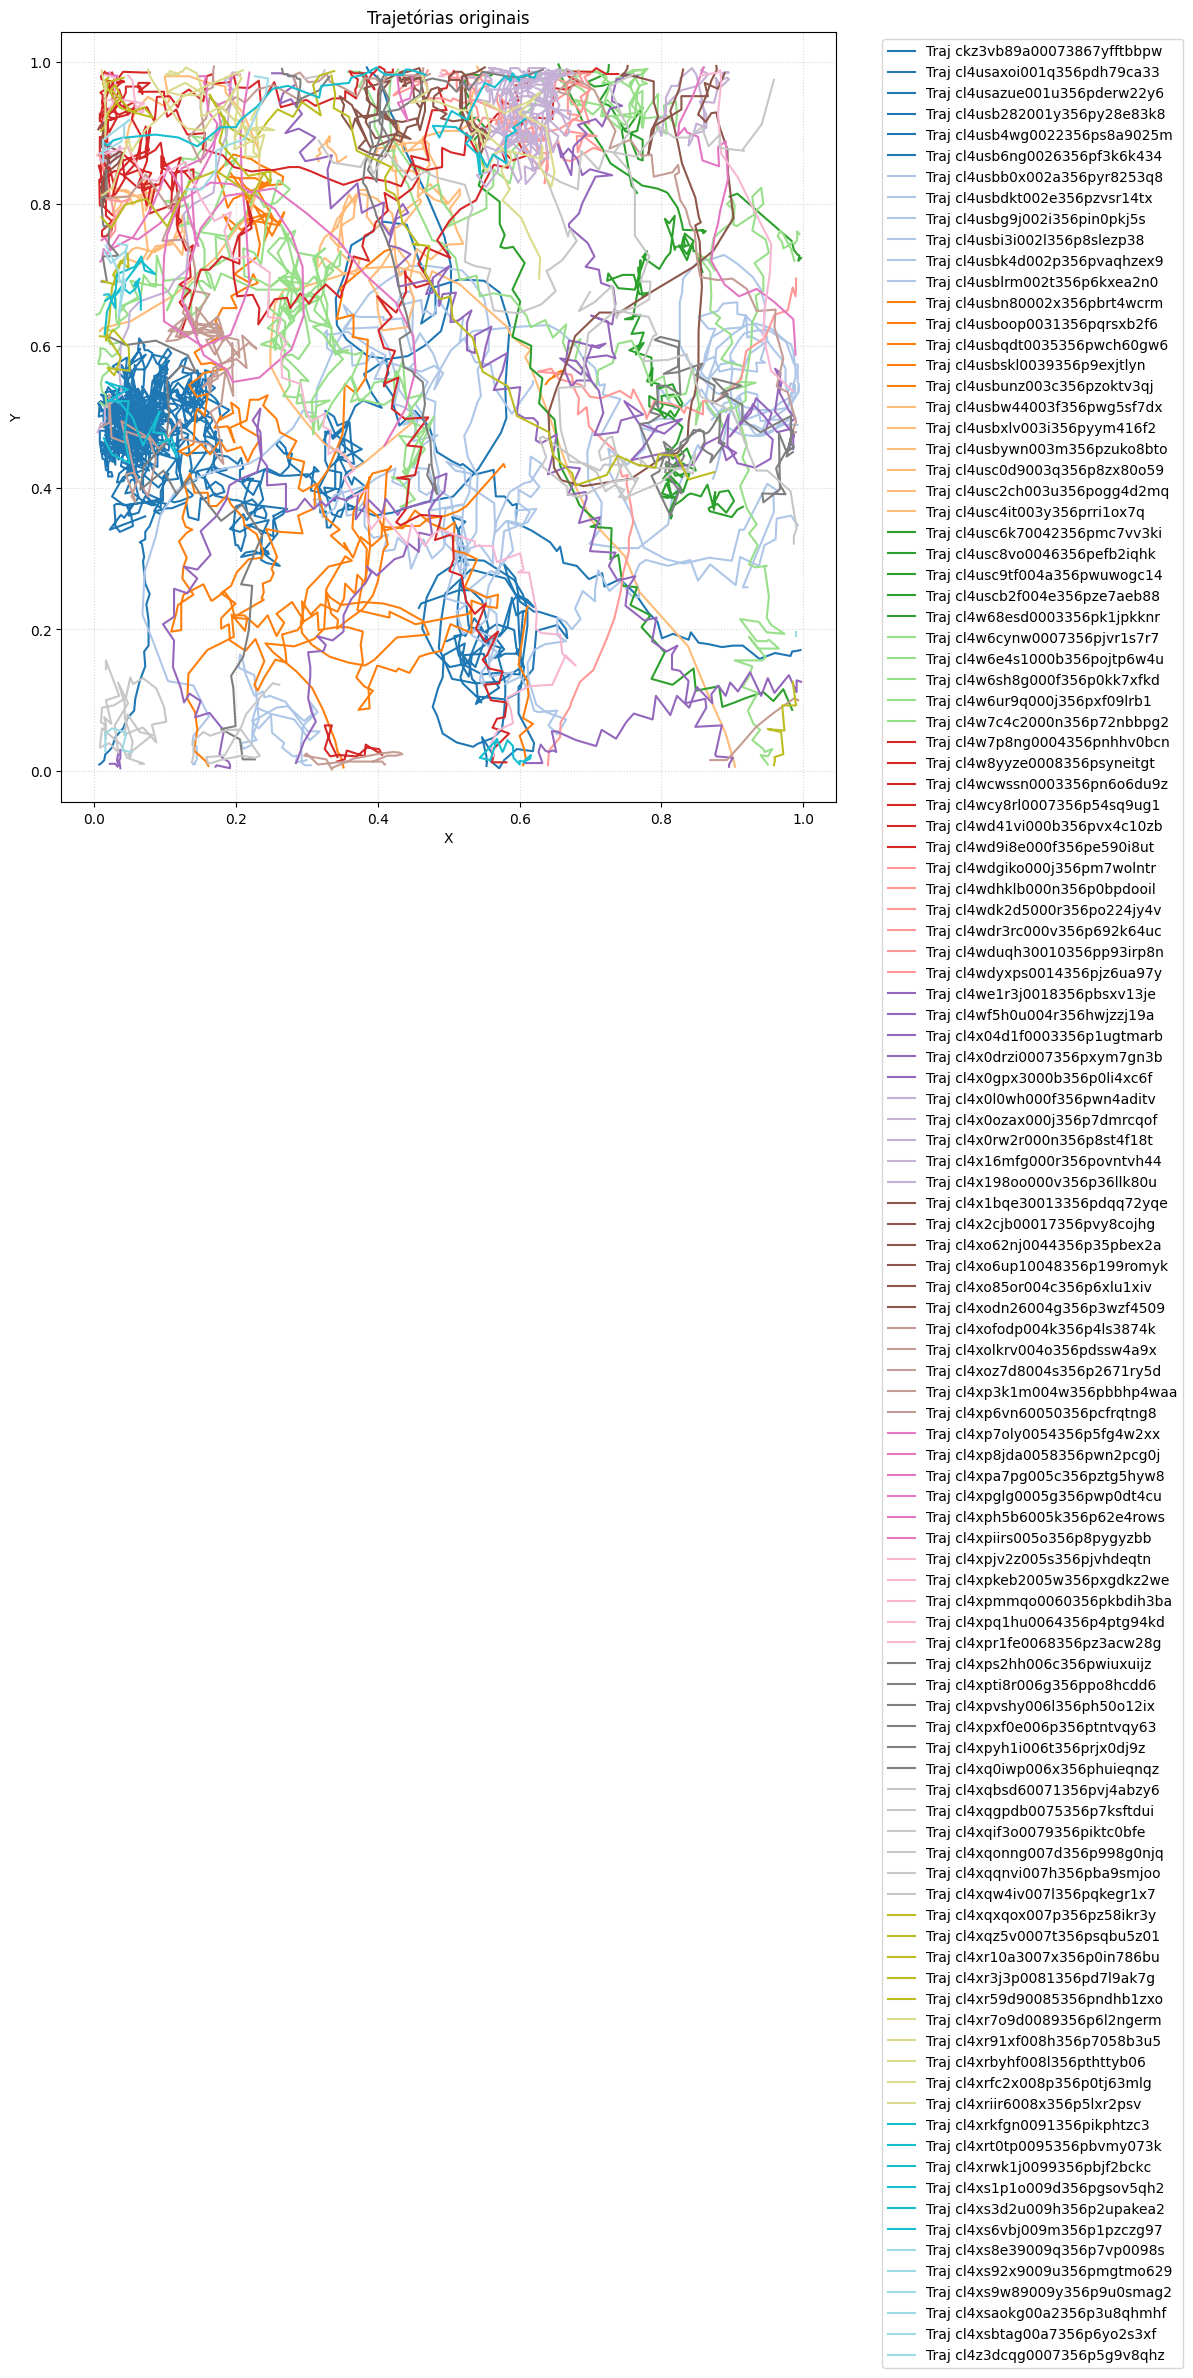

In [25]:
# 2. Plotar trajetórias originais
plt.figure(figsize=(10, 10))
grouped = df_raw.groupby("trajectory_id")
colors = plt.cm.tab20(np.linspace(0, 1, len(grouped)))

for color, (traj_id, g) in zip(colors, grouped):
    g = g.sort_values("timestamp")
    plt.plot(g["x"], g["y"], color=color, label=f"Traj {traj_id}")

plt.title("Trajetórias originais")
plt.xlabel("X"); plt.ylabel("Y")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.axis("equal"); plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir / "traj_orig.png", dpi=300)
plt.show()
plt.close()


Pré-processamento: translação + PCA rotation

In [26]:
df = df_raw.copy()

df['x_translate'] = df.groupby('trajectory_id')['x'].transform(lambda x: x - x.iloc[0])
df['y_translate'] = df.groupby('trajectory_id')['y'].transform(lambda y: y - y.iloc[0])

angles = {}

def pca_angle(x, y):
    X = np.vstack([x, y]).T
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    disp = np.array([x[-1], y[-1]])
    if np.dot(v1, disp) < 0:
        v1 = -v1
    return np.arctan2(v1[1], v1[0])

df['x_rotated'] = np.nan
df['y_rotated'] = np.nan

for tid, g in df.groupby('trajectory_id'):
    x, y = g['x_translate'].to_numpy(), g['y_translate'].to_numpy()
    theta = pca_angle(x, y)
    c, s = np.cos(-theta), np.sin(-theta)
    xr = x * c - y * s
    yr = x * s + y * c
    df.loc[g.index, 'x_rotated'] = xr
    df.loc[g.index, 'y_rotated'] = yr
    angles[tid] = theta


Métricas: Velocidade e ângulo

In [27]:
df = df.sort_values(["trajectory_id", "timestamp"]).reset_index(drop=True)
window = 1

def compute_speed_angle(g):
    dx = g["x_rotated"] - g["x_rotated"].shift(window)
    dy = g["y_rotated"] - g["y_rotated"].shift(window)
    g["speed"] = np.hypot(dx, dy)
    g["angle_deg"] = np.degrees(np.arctan2(dy, dx))
    return g

df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)

C:\Users\ccana\AppData\Local\Temp\ipykernel_4900\2813627076.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)


Discretização simbólica

In [28]:
median_speed = float(np.nanmedian(df["speed"]))
eps = 1e-3 * median_speed if median_speed > 0 else 1e-6
moving = df["speed"] > eps
q25, q75 = np.quantile(df.loc[moving, "speed"], [0.25, 0.75]) if moving.any() else (0, 0)

def label_speed(v):
    if np.isnan(v): return np.nan
    if v <= eps: return "Parado"
    if v <= q25: return "Lento"
    if v <= q75: return "Médio"
    return "Rápido"

def label_dir(a):
    if np.isnan(a): return np.nan
    a = ((a + 180) % 360) - 180
    if -45 < a <= 45: return "Leste"
    if 45 < a <= 135: return "Norte"
    if a > 135 or a <= -135: return "Oeste"
    return "Sul"

df["speed_label"] = df["speed"].apply(label_speed)
df["dir4_label"] = df["angle_deg"].apply(label_dir)

def combine(s, d):
    if pd.isna(s): return ""
    if s == "Parado": return "Parado"
    if pd.isna(d): return ""
    return s + d

df["symbol"] = df.apply(lambda r: combine(r["speed_label"], r["dir4_label"]), axis=1)

# Lista por trajetória
symbolic = df.groupby("trajectory_id").apply(lambda g: g.sort_values("timestamp")["symbol"].tolist())
symbolic = symbolic.rename("simbolic_movement").reset_index()

C:\Users\ccana\AppData\Local\Temp\ipykernel_4900\329799666.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  symbolic = df.groupby("trajectory_id").apply(lambda g: g.sort_values("timestamp")["symbol"].tolist())


Clusterização via MFV + MinHash LSH

In [29]:
from datasketch import MinHash, MinHashLSH
from collections import Counter

k = 4

# MFV
mfvs = []
for seq in symbolic["simbolic_movement"]:
    clean = [s for s in seq if s and pd.notna(s)]
    motifs = [tuple(clean[i:i+k]) for i in range(len(clean)-k+1)]
    c = Counter(motifs)
    total = sum(c.values())
    mfvs.append({m: c[m]/total for m in c})

symbolic["MFV"] = mfvs

# MinHash + LSH
lsh = MinHashLSH(threshold=0.2, num_perm=128)
minhashes = {}

for idx, row in symbolic.iterrows():
    m = MinHash(num_perm=128)
    for motif in row["MFV"].keys():
        m.update(str(motif).encode("utf8"))
    key = f"traj_{row['trajectory_id']}"
    minhashes[key] = m
    lsh.insert(key, m)

buckets = {}
for key in minhashes:
    similar = sorted(lsh.query(minhashes[key]))
    buckets[key] = "_".join(similar)

symbolic["lsh_bucket"] = symbolic["trajectory_id"].apply(lambda g: buckets[f"traj_{g}"])

# Mapear clusters
unique_buckets = {b:i for i,b in enumerate(sorted(set(symbolic["lsh_bucket"])))}
symbolic["cluster_id"] = symbolic["lsh_bucket"].map(unique_buckets)

Behaviour Rugs

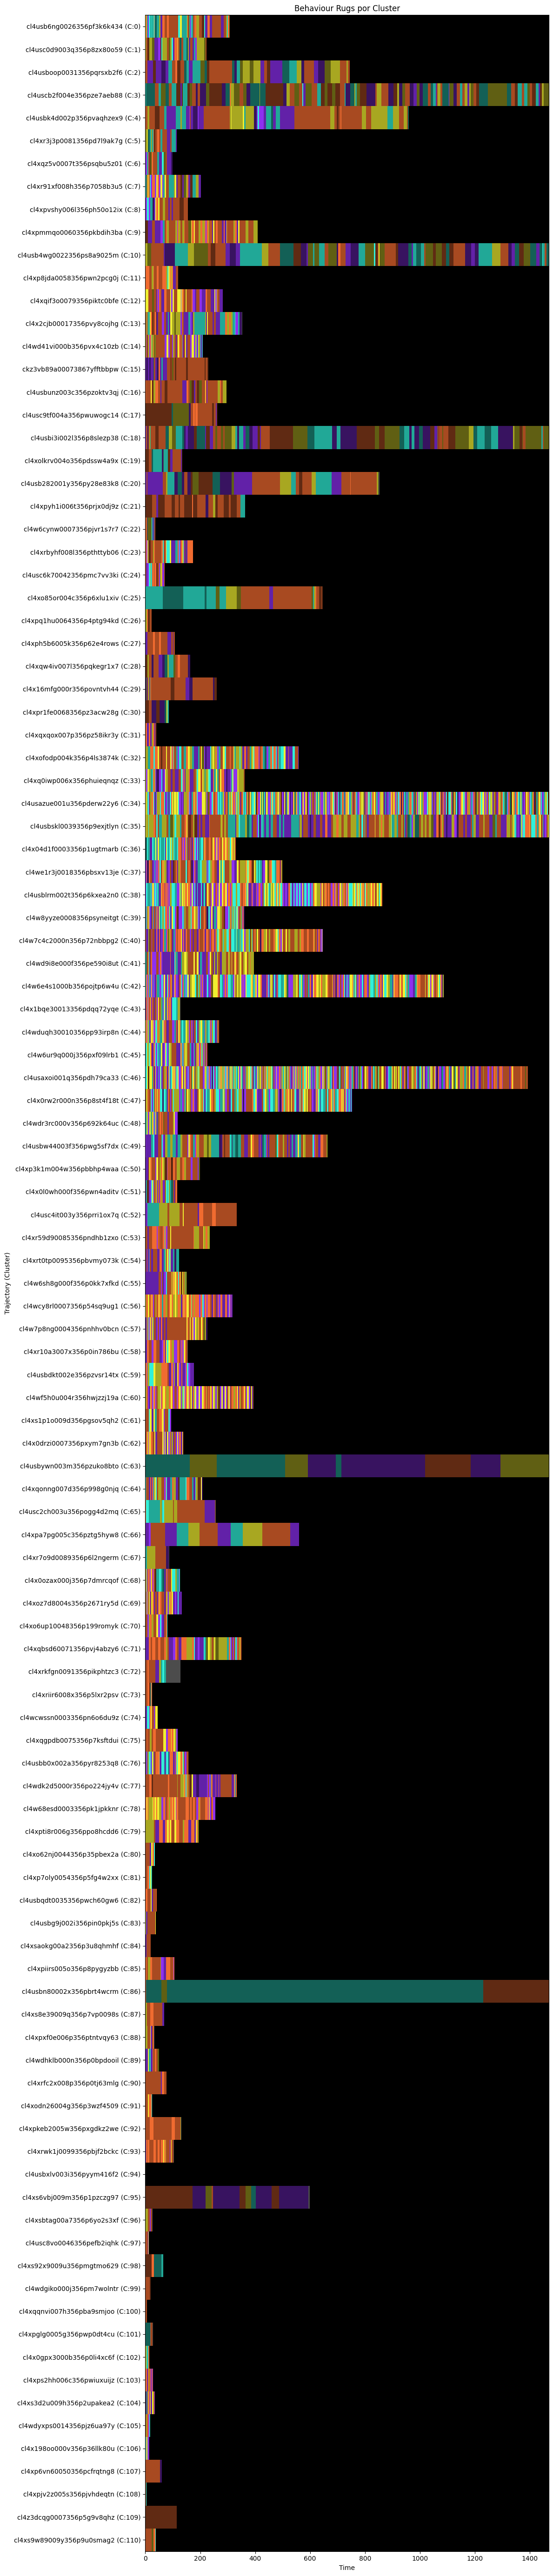

In [30]:
direction_rgb = {
    'Norte':[240/255,239/255,48/255],
    'Leste':[240/255,107/255,48/255],
    'Sul':[141/255,48/255,240/255],
    'Oeste':[48/255,240/255,217/255]
}
speed_factor = {'Parado':0.01,'Lento':0.4,'Médio':0.7,'Rápido':1.0}

def sym2rgb(s):
    if not s or pd.isna(s): return [1,1,1]
    if s == "Parado": return [0.3,0.3,0.3]
    for sp in ["Lento","Médio","Rápido"]:
        if s.startswith(sp):
            d = s[len(sp):]
            base = direction_rgb.get(d, [0,0,0])
            return np.clip(np.array(base)*speed_factor[sp], 0, 1)
    return [0,0,0]

symbolic_sorted = symbolic.sort_values("cluster_id")
max_len = max(len(seq) for seq in symbolic_sorted["simbolic_movement"])
img = np.zeros((len(symbolic_sorted), max_len, 3))

for i, seq in enumerate(symbolic_sorted["simbolic_movement"]):
    row = [sym2rgb(s) for s in seq]
    if len(row) < max_len:
        row += [[0,0,0]]*(max_len-len(row))
    img[i] = row[:max_len]

# --- Behaviour Rugs com legenda de Clusters ---

plt.figure(figsize=(12, 0.5 * len(symbolic_sorted)))

plt.imshow(
    img,
    aspect='auto',
    interpolation='nearest'   # evita borrado
)

# Y labels = id (cluster)
ylabels = symbolic_sorted["trajectory_id"].astype(str) + " (C:" + symbolic_sorted["cluster_id"].astype(str) + ")"
plt.yticks(range(len(symbolic_sorted)), ylabels)

plt.xlabel("Time")
plt.ylabel("Trajectory (Cluster)")
plt.title("Behaviour Rugs por Cluster")

plt.tight_layout()
plt.savefig(output_dir / "behaviourRugs.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
